<a href="https://colab.research.google.com/github/Kazuhiro-Matsui/ECsite/blob/master/Cardiovascular_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 【心血管リスク】循環器疾患予測モデルのデモ
説明：韓国(?)の医療機関で収集された7万人の健康診断データから、陰性を0,陽性を1としたときの陽性リスク(確率)を予測(予測値は[0,1])して評価した。大企業では産業医や産業保健師が全ての従業員の診断データを一人一人チェックしていて、再検査や要検査の従業員をあぶりだすのに膨大な時間がかかっていると聞いている(知り合いの産業保健師からの情報)。診断データから陽性リスクが高そうな従業員をAIで瞬時にスクリーニングできることは、医療現場や企業におけるヘルスケア業務の効率化に直結するだろう。
なお、診断データさえあればどんな疾患リスクも予測できるが、モデルの学習データは目的変数(正解ラベル0か1か)を有するものでなくてはならない。ない場合は、クラスタリング等、潜在変数モデルを作成する必要があるので今回のデモとはまた別のモデルとなる。

データ:https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset/data

技術：R言語で、一般化加法モデル（GAM）の大規模データ用の拡張モデルであるBAMを用いた：

In [ ]:
%load_ext rpy2.ipython


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%%R

# =========================================================
# 0. パッケージの準備と読み込み（必須）
# =========================================================
options(repos = c(CRAN = "https://cloud.r-project.org"), ask = FALSE)
if (!require("dplyr", quietly = TRUE)) install.packages("dplyr", quiet = TRUE)
if (!require("mgcv", quietly = TRUE)) install.packages("mgcv", quiet = TRUE)

library(dplyr)
library(mgcv)

# =========================================================
# 1. データの読み込みとクリーニング・特徴量作成
# =========================================================
cat("--- データの準備を開始します ---\n")
zip_path <- "/content/drive/MyDrive/Cardiovascular Disease/archive.zip"
extract_dir <- "/content/data"
dir.create(extract_dir, showWarnings = FALSE)
unzip(zip_path, exdir = extract_dir)

data_path <- file.path(extract_dir, "cardio_train.csv")
cardio_data <- read.csv(data_path, sep = ";")

# 異常値の排除と、必須列の作成
cardio_data_clean <- cardio_data %>%
  filter(ap_hi >= 70 & ap_hi <= 250) %>%
  filter(ap_lo >= 40 & ap_lo <= 150) %>%
  filter(ap_hi > ap_lo) %>%
  filter(height >= 120 & height <= 210) %>%
  filter(weight >= 30 & weight <= 200) %>%
  mutate(
    age_years = as.numeric(age) / 365.25,
    bmi = weight / ((height / 100)^2),
    pulse_pressure = ap_hi - ap_lo,
    gender = as.factor(gender),
    cholesterol = as.factor(cholesterol),
    gluc = as.factor(gluc),
    smoke = as.factor(smoke),
    alco = as.factor(alco),
    active = as.factor(active),
    cardio = as.factor(cardio)
  )

cat(sprintf("データの準備完了 (データ数: %d件)\n\n", nrow(cardio_data_clean)))

# =========================================================
# 2. モデルの定義とデータの分割
# =========================================================
gam_formula <- cardio ~ gender +
           s(age_years, by = gender) +
           s(bmi, by = gender) +
           s(pulse_pressure, by = gender) +
           s(ap_hi, by = gender) +
           cholesterol + gluc + smoke + alco + active

set.seed(123)
train_idx <- sample(seq_len(nrow(cardio_data_clean)), size = floor(0.8 * nrow(cardio_data_clean)))
train_data <- cardio_data_clean[train_idx, ]
test_data <- cardio_data_clean[-train_idx, ]

# =========================================================
# 3. 5分割交差検証
# =========================================================
fold_ids <- sample(rep(1:5, length.out = nrow(train_data)))
cv_results <- data.frame(Fold = integer(), Accuracy = numeric(),
                         Precision = numeric(), Recall = numeric(), F1 = numeric())

cat("--- 5分割交差検証を開始します (bamによる高速処理) ---\n")
for(i in 1:5) {
  val_idx <- which(fold_ids == i)
  cv_val_data <- train_data[val_idx, ]
  cv_train_data <- train_data[-val_idx, ]

  gam_model_cv <- bam(
    formula = gam_formula,
    family = binomial(link = "logit"),
    data = cv_train_data,
    method = "fREML",
    discrete = TRUE
  )

  pred_probs <- predict(gam_model_cv, newdata = cv_val_data, type = "response")
  pred_classes <- factor(ifelse(pred_probs >= 0.4, 1, 0), levels = c("0", "1"))
  actual_classes <- factor(cv_val_data$cardio, levels = c("0", "1"))

  cm <- table(Predicted = pred_classes, Actual = actual_classes)
  TP <- cm["1", "1"]; TN <- cm["0", "0"]; FP <- cm["1", "0"]; FN <- cm["0", "1"]

  acc  <- (TP + TN) / sum(cm)
  prec <- TP / (TP + FP)
  rec  <- TP / (TP + FN)
  f1   <- 2 * (prec * rec) / (prec + rec)

  cv_results <- rbind(cv_results, data.frame(Fold = i, Accuracy = acc,
                                             Precision = prec, Recall = rec, F1 = f1))
  cat(sprintf("Fold %d 完了\n", i))
}

cat("\n[クロスバリデーションの平均スコア]\n")
print(colMeans(cv_results[, -1]))

# =========================================================
# 4. 最終モデルの構築と評価（通常 ＆ 安全重視フェイルセーフ）
# =========================================================
cat("\n--- テストデータでの最終評価と不確実性の算出 ---\n")

final_gam_model <- bam(
  formula = gam_formula,
  family = binomial(link = "logit"),
  data = train_data,
  method = "fREML",
  discrete = TRUE
)

pred_obj <- predict(final_gam_model, newdata = test_data, type = "link", se.fit = TRUE)
fit_link <- pred_obj$fit
se_link  <- pred_obj$se.fit

prob_fit   <- plogis(fit_link)
prob_upper <- plogis(fit_link + 1.96 * se_link)
prob_lower <- plogis(fit_link - 1.96 * se_link)

# --- 通常の評価（点推定が0.4以上なら陽性） ---
test_preds <- factor(ifelse(prob_fit >= 0.4, 1, 0), levels = c("0", "1"))
test_actual <- factor(test_data$cardio, levels = c("0", "1"))

test_cm <- table(Predicted = test_preds, Actual = test_actual)
t_TP <- test_cm["1", "1"]; t_TN <- test_cm["0", "0"]; t_FP <- test_cm["1", "0"]; t_FN <- test_cm["0", "1"]

cat("\n[通常評価 (AIの予測確率が0.4以上なら陽性)]\n")
cat(sprintf("Accuracy  : %.4f\n", (t_TP + t_TN) / sum(test_cm)))
cat(sprintf("Precision : %.4f\n", t_TP / (t_TP + t_FP)))
cat(sprintf("Recall    : %.4f\n", t_TP / (t_TP + t_FN)))
cat(sprintf("F1-score  : %.4f\n", 2 * (t_TP / (t_TP + t_FP) * (t_TP / (t_TP + t_FN))) / ((t_TP / (t_TP + t_FP)) + (t_TP / (t_TP + t_FN)))))

# --- 保守的な評価（95%区間の上限が0.4以上なら陽性とするフェイルセーフ） ---
test_preds_safe <- factor(ifelse(prob_upper >= 0.4, 1, 0), levels = c("0", "1"))
test_cm_safe <- table(Predicted = test_preds_safe, Actual = test_actual)
s_TP <- test_cm_safe["1", "1"]; s_TN <- test_cm_safe["0", "0"]; s_FP <- test_cm_safe["1", "0"]; s_FN <- test_cm_safe["0", "1"]

cat("\n[安全重視の保守的評価 (95%区間上限が0.4以上なら陽性)]\n")
cat(sprintf("Accuracy  : %.4f\n", (s_TP + s_TN) / sum(test_cm_safe)))
cat(sprintf("Precision : %.4f\n", s_TP / (s_TP + s_FP)))
cat(sprintf("Recall    : %.4f\n", s_TP / (s_TP + s_FN)))
cat(sprintf("F1-score  : %.4f\n", 2 * (s_TP / (s_TP + s_FP) * (s_TP / (s_TP + s_FN))) / ((s_TP / (s_TP + s_FP)) + (s_TP / (s_TP + s_FN)))))


--- データの準備を開始します ---
データの準備完了 (データ数: 68610件)

--- 5分割交差検証を開始します (bamによる高速処理) ---
Fold 1 完了
Fold 2 完了
Fold 3 完了
Fold 4 完了
Fold 5 完了

[クロスバリデーションの平均スコア]
 Accuracy Precision    Recall        F1 
0.7296860 0.7146213 0.7545091 0.7339815 

--- テストデータでの最終評価と不確実性の算出 ---

[通常評価 (AIの予測確率が0.4以上なら陽性)]
Accuracy  : 0.7260
Precision : 0.7128
Recall    : 0.7502
F1-score  : 0.7310

[安全重視の保守的評価 (95%区間上限が0.4以上なら陽性)]
Accuracy  : 0.7202
Precision : 0.6954
Recall    : 0.7761
F1-score  : 0.7335


In [ ]:
%%R
# 5. 予測結果と不確実性の表示
# =========================================================
uncertainty_results <- data.frame(
  Actual = test_data$cardio,
  Prob_Estimate = round(prob_fit, 3),
  Prob_Lower_95 = round(prob_lower, 3),
  Prob_Upper_95 = round(prob_upper, 3),
  Uncertainty_Width = round(prob_upper - prob_lower, 3)
)

cat("--- 予測結果の最初の15行 ---\n")
print(head(uncertainty_results, 15))

--- 予測結果の最初の15行 ---
   Actual Prob_Estimate Prob_Lower_95 Prob_Upper_95 Uncertainty_Width
1       0         0.236         0.215         0.258             0.043
4       1         0.869         0.851         0.885             0.035
11      0         0.477         0.457         0.498             0.041
22      0         0.578         0.558         0.598             0.040
24      0         0.276         0.238         0.318             0.080
27      0         0.533         0.512         0.554             0.042
29      0         0.166         0.147         0.187             0.040
35      1         0.944         0.936         0.951             0.015
39      1         0.623         0.587         0.658             0.071
42      1         0.176         0.162         0.192             0.030
44      1         0.276         0.250         0.303             0.052
45      1         0.913         0.888         0.934             0.046
51      0         0.179         0.159         0.201             0.041


In [ ]:
%%R
summary(final_gam_model)



Family: binomial 
Link function: logit 

Formula:
cardio ~ gender + s(age_years, by = gender) + s(bmi, by = gender) + 
    s(pulse_pressure, by = gender) + s(ap_hi, by = gender) + 
    cholesterol + gluc + smoke + alco + active

Parametric coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)   0.71427    0.08416   8.487  < 2e-16 ***
gender2       0.21052    0.13171   1.598    0.110    
cholesterol2  0.31180    0.03115  10.009  < 2e-16 ***
cholesterol3  1.05434    0.04073  25.886  < 2e-16 ***
gluc2         0.01620    0.04082   0.397    0.691    
gluc3        -0.32825    0.04535  -7.238 4.55e-13 ***
smoke1       -0.18307    0.03977  -4.603 4.16e-06 ***
alco1        -0.20113    0.04819  -4.173 3.00e-05 ***
active1      -0.22439    0.02487  -9.021  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
                            edf Ref.df  Chi.sq  p-value    
s(age_years):gender1      7.200  8.

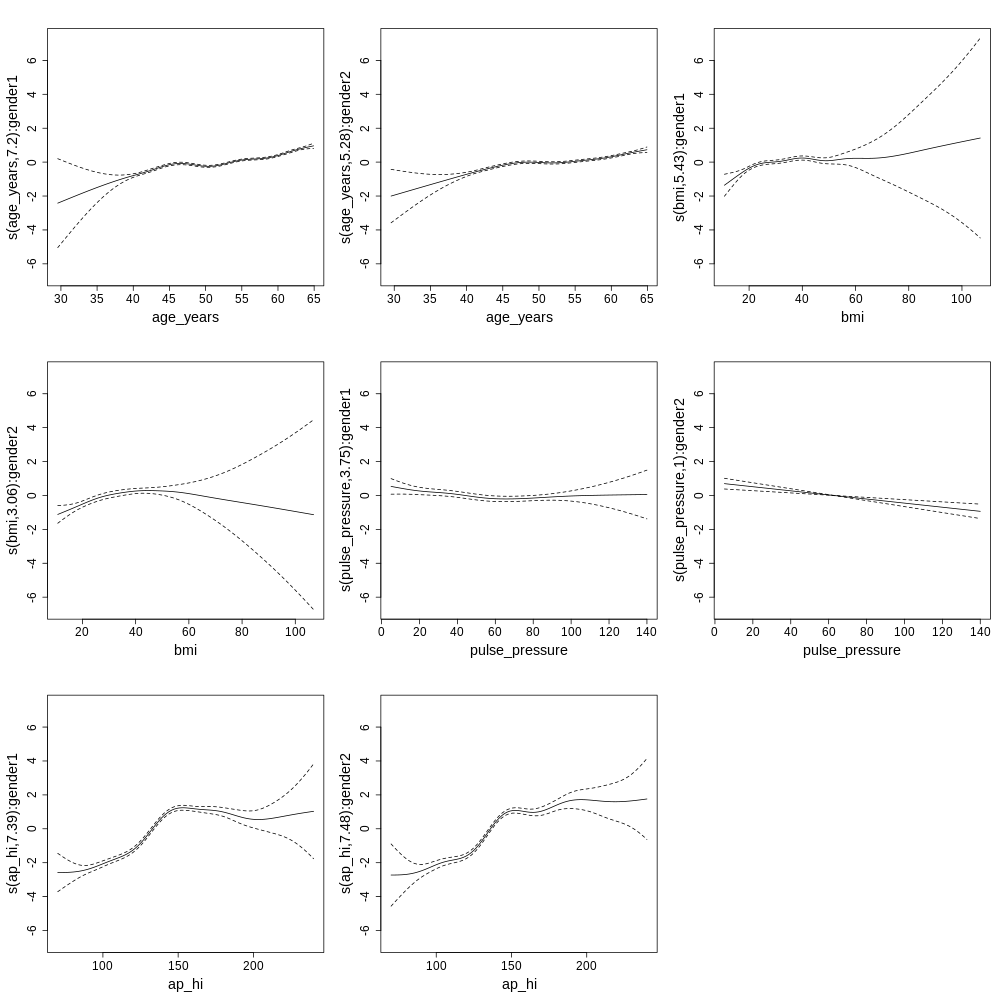

In [ ]:
%%R -w 1000 -h 1000

# cex.lab で軸ラベルの文字を1.8倍、cex.axis で数字を1.5倍に拡大
plot(final_gam_model, pages=1, cex.lab=1.8, cex.axis=1.5)


# 総評

このKaggleの「心血管疾患データセット」は、健康診断の基本的な項目（血液検査の一部と血圧・体型など）しか含まれていないため、Accuracy（精度）の上限は概ね 73%〜74%程度が限界（どんなAIを使ってもこれ以上は上がらない） と言われている。

医療やヘルスケアの分野においては、AIの評価指標として適合率（Precision）よりも再現率（Recall）が重視されるべきである（偽陰性を極力なくすことが最優先のため)。

つまり、現在の Accuracy 72.6% / Recall 75.1% という数字は、このデータセットにおける最高到達点に近い性能である。

summaryから、収縮期血圧が予測に最も大きな影響を与えていることが分かった。(カイ二乗値)

また、個人的に興味深かったのは喫煙・飲酒・高血糖値でリスクが下がるという直感に反する現象が起きていることである。
smoke1（喫煙）、alco1（飲酒）、gluc3（重度の高血糖）の係数がマイナスになっている現象は、AIが間違えたのではなく、今回のデータに以下のような強いバイアス（偏り）が潜んでいることが原因だと考えられる。

理由A：逆因果関係（治療・行動変容バイアス） これが最も大きな原因だろう。このデータは「ある時点での健康診断結果」である。 心血管疾患のリスクが高い人（あるいはすでに自覚症状がある人）は、医師から強く指導され、「すでにタバコや酒をやめている（smoke=0, alco=0）」可能性が非常に高い。逆に、健康に自信がある人ほどタバコやお酒を楽しんでいる。 また、血糖値が極端に高い人（gluc3）は、すでに厳しい食事制限や強力な薬物治療を受けてコントロールしている状態かもしれない。モデルは「タバコを吸っている＝比較的健康な証拠」「タバコを吸っていない＝病気だからやめさせられた人」という「相関関係」を拾ってしまったと考えられる。

理由B：強い交絡変数（性別）によるマスキング このデータセットでは、「喫煙者と飲酒者の圧倒的多数が男性である」という強い偏りがある。 モデルの出力を見ると、男性（gender2）であるだけで +0.21 のリスクが加算され、さらに男性に多い高血圧（s(ap_hi):gender2）で大きなリスクが加算されています。 すでに「男性」と「血圧」で十分に高い疾患リスクが計算されているため、統計モデルが数式の帳尻を合わせる際、残った「喫煙」の要素が数学的に押し出されてマイナスに振れてしまったと考えられる（多重共線性やシンプソンのパラドックスに近い現象）。
まとめると、単純な予測精度は73%と高いが、喫煙や飲酒の係数がマイナスになることから、このデータには行動変容バイアス（病気の人は生活習慣を改善している）が含まれており、予防医学の因果関係を示す根拠としては使えない。

・実運用

このデモのモデルでは偽陰性を極力減らすために、0.4以上を陽性と評価し再現率を最大化した。適合率が0.7と、実際には偽陽性が30%ほど含まれているので、医療スクリーニングにおける「役割分担として今回の予測モデルのようなAIは、病院での最終診断を下すためのものではなく、健康診断のデータから陽性かもしれない人を拾い上げる（スクリーニングする）」という一次フィルターの役割を果たす。
二次フィルター（医師・精密検査の役割）として、 AIがすくい上げた人たちを詳しく調べ、本当に病気の人だけを確定診断する。ここで初めて適合率（Precision）を高める作業を行うという診断フローを組む必要がある。